In [1]:
# Fill missing data in csv files with 0
# # some of the csv are missing data for some datetimes
# # i want to fill the missing data with 0 all data for the same datetime
# import pandas as pd
# import datetime
# from glob import glob
# import numpy

# # got a filename that has all the datetimes with prices
# filename = 'data/SP500.csv'
# #get the list of datetimes in the field timestamp with pandas

# df = pd.read_csv(filename)
# datetimes = df['timestamp'].to_list()

# # get the list of csv files
# files = glob('Data/*.csv')

# # This is a sample of the format of the csv files
# #timestamp,symbol,open,high,low,close,volume,trade_count,vwap
# #2016-06-01 09:30:00-04:00,QSII,12.69,12.74,12.65,12.67,48037.0,208.0,12.706119

# # for each file in the list: 
# # create a new file with the same name +"_filled" , put all the datetimes in the first column with the same format
# # timestamp,symbol,open,high,low,close,volume,trade_count,vwap
# # keep the same order of the columns 
# # if exists data for a datetime, keep the data
# # if there is no data for a datetime, fill the data with 0
# # process the files with pandas

# for file in files:
#     print('Processing file', file)
#     df = pd.read_csv(file)
#     #df['timestamp'] = pd.to_datetime(df['timestamp'])
#     df = df.set_index('timestamp')
#     df.drop_duplicates(keep='first', inplace=True)
#     df = df.reindex(datetimes, fill_value=0)
#     df = df.reset_index()
#     df.to_csv(file.replace('Data/', 'Data/filled_'), index=False)
#     print('File', file, 'processed')

In [2]:
# #Convert to parquet
# from glob import glob
# import pandas as pd


# files = glob('Data/*.csv')

# for file in files:
#     parquet_file_name = file.replace('.csv', '.pk')
#     print(f'Processing file: {file} to {parquet_file_name}')
#     df = pd.read_csv(file, index_col='timestamp', parse_dates=True)
#     # Drop column symbol
#     df.drop(columns='symbol', inplace=True)
#     if parquet_file_name[-3:] == '.pk':
#         df.to_parquet(parquet_file_name, index=True)
#         print("The file was saved as parquet: {parquet_file_name}")

In [3]:
import pandas as pd
from datetime import datetime

# Danh sách các cổ phiếu trong Dow Jones 30
tickers = ['AAPL','ABCB','ABNB','BFR','BRCD','CSCO','DAL','EAST','ESPR','F',
           'FFIE','GOOGL','JPM','JTAI','META','MSFT','NVDA','PFE','PG','PSX',
           'QSII', 'SGLY','SP500','TSLA','UNH','USA','WMT','XOM']

# ticker of benchmark
benchmark = 'SP500'

# Get the data from the CSV files
stock_data = {}
for ticker in tickers:
    df = pd.read_parquet(f'Data/{ticker}.pk')
    #pass the columns to capitalize
    df.columns = df.columns.str.capitalize()
    stock_data[ticker] = df


# Establish the time range for the data
#trainInit = datetime.fromisoformat('2016-06-01 00:00:01-04:00')
trainInit = datetime.fromisoformat('2019-06-01 00:00:01-04:00')
trainEnd = datetime.fromisoformat('2020-06-01 00:00:01-04:00')
testInit = datetime.fromisoformat('2020-06-02 00:00:01-04:00')
testEnd = datetime.fromisoformat('2021-06-01 00:00:01-04:00')
#testEnd = datetime.fromisoformat('2024-03-01 00:00:01-04:00')

# split the data into training, validation and test sets
training_data_time_range = (trainInit, trainEnd)
test_data_time_range = (testInit, testEnd)

# split the data into training, validation and test sets
training_data = {}
validation_data = {}
test_data = {}

for ticker, df in stock_data.items():
    training_data[ticker] = df.loc[training_data_time_range[0]:training_data_time_range[1]]
    test_data[ticker] = df.loc[test_data_time_range[0]:test_data_time_range[1]]

# print shape of training, validation and test data
ticker = 'AAPL'
print(f'Training data shape for {ticker}: {training_data[ticker].shape}')
print(f'Test data shape for {ticker}: {test_data[ticker].shape}')

# Display the first 5 rows of the data
stock_data['AAPL'].head()

Training data shape for AAPL: (15595, 7)
Test data shape for AAPL: (15664, 7)


,Open,High,Low,Close,Volume,Trade_count,Vwap
timestamp,,,,,,,
2016-06-01 04:00:00-04:00,99.88,99.98,99.88,99.98,517.0,9.0,99.957447
2016-06-01 04:15:00-04:00,0.00,0.00,0.00,0.00,0.0,0.0,0.000000
2016-06-01 04:30:00-04:00,0.00,0.00,0.00,0.00,0.0,0.0,0.000000
2016-06-01 04:45:00-04:00,99.61,99.61,99.30,99.50,1490.0,10.0,99.497651
2016-06-01 05:00:00-04:00,99.38,99.52,99.38,99.52,527.0,4.0,99.425863


In [4]:
import pandas as pd
import numpy as np

def add_technical_indicators(df):
    # calculate RSI 14 
    delta = df['Close'].diff()
    up = delta.where(delta > 0, 0)
    down = -delta.where(delta < 0, 0)
    rs = up.rolling(window=14).mean() / down.rolling(window=14).mean()
    df['RSI'] = 100 - (100 / (1 + rs))

    # EMA 12 / 26  en MACD
    df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = df['EMA12'] - df['EMA26']
    df['Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    
    # RSI 14
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    
    # CCI 20
    tp = (df['High'] + df['Low'] + df['Close']) / 3
    sma_tp = tp.rolling(window=20).mean()
    mean_dev = tp.rolling(window=20).apply(lambda x: np.mean(np.abs(x - x.mean())))
    df['CCI'] = (tp - sma_tp) / (0.015 * mean_dev)
    
    # ADX 14
    high_diff = df['High'].diff()
    low_diff = df['Low'].diff()
    df['+DM'] = np.where((high_diff > low_diff) & (high_diff > 0), high_diff, 0)
    df['-DM'] = np.where((low_diff > high_diff) & (low_diff > 0), low_diff, 0)
    tr = pd.concat([df['High'] - df['Low'], np.abs(df['High'] - df['Close'].shift(1)), np.abs(df['Low'] - df['Close'].shift(1))], axis=1).max(axis=1)
    atr = tr.ewm(span=14, adjust=False).mean()
    df['+DI'] = 100 * (df['+DM'].ewm(span=14, adjust=False).mean() / atr)
    df['-DI'] = 100 * (df['-DM'].ewm(span=14, adjust=False).mean() / atr)
    dx = 100 * np.abs(df['+DI'] - df['-DI']) / (df['+DI'] + df['-DI'])
    df['ADX'] = dx.ewm(span=14, adjust=False).mean()

    # drop NaN values
    df.dropna(inplace=True)

    # keep Open, High, Low, Close, Volume, MACD, Signal, RSI, CCI, ADX
    df = df[['Open', 'High', 'Low', 'Close', 'Volume', 'MACD', 'Signal', 'RSI', 'CCI', 'ADX']]

    return df

In [5]:
# add technical indicators to the training data for each stock
for ticker, df in training_data.items():
    training_data[ticker] = add_technical_indicators(df)

# add technical indicators to the test data for each stock
for ticker, df in test_data.items():
    test_data[ticker] = add_technical_indicators(df)


# Create benchmark data
benchmark_training_data = training_data[benchmark]
benchmark_test_data = test_data[benchmark]

# print the first 5 rows of the data
print('Shape of training data for AAPL:', training_data['AAPL'].shape)
print('Shape of test data for AAPL:', test_data['AAPL'].shape)

# print the first 5 rows of the benchmark data
print('Shape of training benchmark data:', benchmark_training_data.shape)
print('Shape of test benchmark data:', benchmark_test_data.shape)

C:\Users\tcorn\AppData\Local\Temp\ipykernel_24660\3622855247.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['RSI'] = 100 - (100 / (1 + rs))
C:\Users\tcorn\AppData\Local\Temp\ipykernel_24660\3622855247.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
C:\Users\tcorn\AppData\Local\Temp\ipykernel_24660\3622855247.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "c:\Users\tcorn\Desktop\RLTesis\DRLST\lib\site-packages\IPython\core\interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\tcorn\AppData\Local\Temp\ipykernel_24660\3700184032.py", line 3, in <module>
    training_data[ticker] = add_technical_indicators(df)
  File "C:\Users\tcorn\AppData\Local\Temp\ipykernel_24660\3622855247.py", line 28, in add_technical_indicators
    mean_dev = tp.rolling(window=20).apply(lambda x: np.mean(np.abs(x - x.mean())))
  File "c:\Users\tcorn\Desktop\RLTesis\DRLST\lib\site-packages\pandas\core\window\rolling.py", line 1913, in apply
    return super().apply(
  File "c:\Users\tcorn\Desktop\RLTesis\DRLST\lib\site-packages\pandas\core\window\rolling.py", line 1390, in apply
    return self._apply(
  File "c:\Users\tcorn\Desktop\RLTesis\DRLST\lib\site-packages\pandas\core\window\rolling.py", line 615, in _apply
    return self._apply_blockwise(homogeneous_func

In [6]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd

class StockTradingEnv(gym.Env):
    metadata = {'render_modes': ['human']}
    
    def __init__(self, stock_data , benchmark_data, return_memory_size=5):
        super(StockTradingEnv, self).__init__()

        # Define the benchmark
        self.benchmark_data = benchmark_data

        # Initialize of memory
        self.return_memory_size = return_memory_size
        self.last_return_memory_benchmark = []
        self.last_return_memory_portfolio = []
        self.benchmark_portfolio_correlation = 0

        self.total_return_memory_benchmark = []
        self.total_return_memory_portfolio = []
        self.benchmark_portfolio_total_correlation = 0

        # Remove any empty DataFrames from the stock data
        self.stock_data = {ticker: df for ticker, df in stock_data.items() if not df.empty}     
        self.tickers = list(self.stock_data.keys())
        print(f"Stock data has been loaded for {len(self.tickers)} stocks.")
        print(f"The tickers are: {self.tickers}")
        
        if not self.tickers:
            raise ValueError("All provided stock data is empty")
        
        # Calculate the size of one stock's data
        sample_df = next(iter(self.stock_data.values()))
        self.n_features = len(sample_df.columns)
        
        # Define action and observation space
        self.action_space = spaces.Box(low=-1, high=1, shape=(len(self.tickers),), dtype=np.float32)
        
        # Observation space: price data for each stock + balance + net worth + shares held + max net worth + current step
        self.obs_shape = self.n_features * len(self.tickers) + 2 + len(self.tickers) + 2
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.obs_shape,), dtype=np.float32)
        
        # Initialize account balance
        self.initial_balance = 100000
        self.balance = self.initial_balance
        self.net_worth = self.initial_balance
        self.last_net_worth = self.initial_balance
        self.max_net_worth = self.initial_balance
        self.shares_held = {ticker: 0 for ticker in self.tickers}
        self.total_shares_sold = {ticker: 0 for ticker in self.tickers}
        self.total_sales_value = {ticker: 0 for ticker in self.tickers}
        
        # Set the current step
        self.current_step = 0
        
        # Calculate the minimum length of data across all stocks
        self.max_steps = max(0, min(len(df) for df in self.stock_data.values()) - 1)
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.balance = self.initial_balance
        self.net_worth = self.initial_balance
        self.last_net_worth = self.initial_balance
        self.max_net_worth = self.initial_balance
        self.shares_held = {ticker: 0 for ticker in self.tickers}
        self.total_shares_sold = {ticker: 0 for ticker in self.tickers}
        self.total_sales_value = {ticker: 0 for ticker in self.tickers}
        self.current_step = 0
        self.last_return_memory_benchmark = []
        self.last_return_memory_portfolio = []

        self.total_return_memory_benchmark = []
        self.total_return_memory_portfolio = []

        self.benchmark_portfolio_correlation = 0
        self.benchmark_portfolio_total_correlation = 0

        return self._next_observation(), {}
    
    def _next_observation(self):
        frame = np.zeros(self.obs_shape)
        
        idx = 0
        for ticker in self.tickers:
            df = self.stock_data[ticker]
            if self.current_step < len(df):
                frame[idx:idx+self.n_features] = df.iloc[self.current_step].values
            elif len(df) > 0:
                frame[idx:idx+self.n_features] = df.iloc[-1].values
            idx += self.n_features
        
        frame[-4-len(self.tickers)] = self.balance
        frame[-3-len(self.tickers):-3] = [self.shares_held[ticker] for ticker in self.tickers]
        frame[-3] = self.net_worth
        frame[-2] = self.max_net_worth
        frame[-1] = self.current_step
        
        return frame
    
    def step(self, actions):
        self.current_step += 1
        
        if self.current_step > self.max_steps:
            return self._next_observation(), 0, True, False, {}
        
        current_prices = {}
        for i, ticker in enumerate(self.tickers):
            current_prices[ticker] = self.stock_data[ticker].iloc[self.current_step]['Close']
            action = actions[i]
            
            # Buy or sell the stocks just if the price is different from 0
            if current_prices[ticker] != 0.0:
                if action > 0:  # Buy
                    shares_to_buy = int(self.balance * action / current_prices[ticker])
                    cost = shares_to_buy * current_prices[ticker]
                    self.balance -= cost
                    self.shares_held[ticker] += shares_to_buy
                elif action < 0:  # Sell
                    shares_to_sell = int(self.shares_held[ticker] * abs(action))
                    sale = shares_to_sell * current_prices[ticker]
                    self.balance += sale
                    self.shares_held[ticker] -= shares_to_sell
                    self.total_shares_sold[ticker] += shares_to_sell
                    self.total_sales_value[ticker] += sale
        

        self.last_net_worth = self.net_worth
        self.net_worth = self.balance + sum(self.shares_held[ticker] * current_prices[ticker] for ticker in self.tickers)
        self.max_net_worth = max(self.net_worth, self.max_net_worth)
        
        reward = self.net_worth - self.initial_balance
        done = self.net_worth <= 0 or self.current_step >= self.max_steps

        # Calculate the return of the benchmark (just from second step)
        if self.current_step > 0:
            benchmark_return = self.benchmark_data.iloc[self.current_step]['Close'] / self.benchmark_data.iloc[self.current_step - 1]['Close'] - 1
            #Add the return to the benchmark to the memory but if the memory is full, remove the oldest return
            if len(self.last_return_memory_benchmark) >= self.return_memory_size:
                self.last_return_memory_benchmark.pop(0)
            self.last_return_memory_benchmark.append(benchmark_return)
            

            # Calculate the return of the portfolio
            portfolio_return = self.net_worth / self.last_net_worth - 1
            # Add the return to the portfolio to the memory but if the memory is full, remove the oldest return
            if len(self.last_return_memory_portfolio) >= self.return_memory_size:
                self.last_return_memory_portfolio.pop(0)
            self.last_return_memory_portfolio.append(portfolio_return)

        
        # Calculate the pearson correlation between the benchmark memory and the portfolio memory just if the memory is full
        if len(self.last_return_memory_benchmark) == self.return_memory_size and \
           len(self.last_return_memory_portfolio) == self.return_memory_size:
            self.benchmark_portfolio_correlation = np.corrcoef(self.last_return_memory_benchmark, self.last_return_memory_portfolio)[0][1]   
        else:
            self.benchmark_portfolio_correlation = 0
        
        obs = self._next_observation()
        return obs, reward, done, False, {}
    
    def render(self, mode='human'):
        profit = self.net_worth - self.initial_balance
        print(f'Step: {self.current_step}')
        print(f'Benchmark-Portfolio Correlation: {self.benchmark_portfolio_correlation:.2f}')
        print(f'Balance: {self.balance:.2f}')
        for ticker in self.tickers:
            print(f'{ticker} Shares held: {self.shares_held[ticker]}')
        print(f'Net worth: {self.net_worth:.2f}')
        print(f'Profit: {profit:.2f}')

    def close(self):
        pass

    def update_stock_data(self, new_stock_data):
        """
        Actualice el entorno con el nuevo conjunto de datos de acciones.

        Parámetros:
        new_stock_data (dict): diccionario que contiene datos de nuevas acciones, 
                                siendo la clave el código de stock y el valor el DataFrame.
        """
        # Elimina DataFrame vacios
        self.stock_data = {ticker: df for ticker, df in new_stock_data.items() if not df.empty}
        self.tickers = list(self.stock_data.keys())

        if not self.tickers:
            raise ValueError("Todos los datos de acciones nuevas están vacíos")

        # Actualizar el número de características
        sample_df = next(iter(self.stock_data.values()))
        self.n_features = len(sample_df.columns)

        # Actualizar espacio de observación
        self.obs_shape = self.n_features * len(self.tickers) + 2 + len(self.tickers) + 2
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.obs_shape,), dtype=np.float32)

        # Actualizar el número máximo de pasos
        self.max_steps = max(0, min(len(df) for df in self.stock_data.values()) - 1)

        # Resetea el entorno
        self.reset()

        print(f"El entorno se ha actualizado con nuevos recursos {len(self.tickers)}.")

In [7]:
from stable_baselines3.common.utils import get_device

In [8]:
get_device(device='cuda')

device(type='cuda')

In [9]:
from stable_baselines3 import PPO, A2C, DDPG
from stable_baselines3.common.vec_env import DummyVecEnv

# Define Ensemble Agent
class EnsembleAgent:
    def __init__(self, ppo_model, a2c_model, ddpg_model):
        self.ppo_model = ppo_model
        self.a2c_model = a2c_model
        self.ddpg_model = ddpg_model
    
    def predict(self, obs):
        ppo_action, _ = self.ppo_model.predict(obs)
        a2c_action, _ = self.a2c_model.predict(obs)
        ddpg_action, _ = self.ddpg_model.predict(obs)
        
        # Average the actions
        ensemble_action = np.mean([ppo_action, a2c_action, ddpg_action], axis=0)
        return ensemble_action
    
# Define PPO Agent
class PPOAgent:
    def __init__(self, env, total_timesteps):
        self.model = PPO("MlpPolicy", env, verbose=1, device='cuda')
        self.model.learn(total_timesteps=total_timesteps)
    
    def predict(self, obs):
        action, _ = self.model.predict(obs)
        return action
    
# Define A2C Agent
class A2CAgent:
    def __init__(self, env, total_timesteps):
        self.model = A2C("MlpPolicy", env, verbose=1, device='cuda')
        self.model.learn(total_timesteps=total_timesteps)
    
    def predict(self, obs):
        action, _ = self.model.predict(obs)
        return action
    
# Define DDPG Agent
class DDPGAgent:
    def __init__(self, env, total_timesteps):
        self.model = DDPG("MlpPolicy", env, verbose=1, device='cuda')
        self.model.learn(total_timesteps=total_timesteps)
    
    def predict(self, obs):
        action, _ = self.model.predict(obs)
        return action
    
# Define Random Agent
class RandomAgent:
    def __init__(self, env):
        self.env = env
        self.tickers_len = len(env.get_attr('tickers')[0])
    
    def predict(self, obs):
        return np.random.uniform(-1, 1, self.tickers_len).reshape(1, self.tickers_len)

# Define SP500 Agent
class SP500Agent:
    def __init__(self, env):
        self.env = env
        self.tickers = env.get_attr('tickers')[0]
        self.tickers_len = len(self.tickers)
        self.SP500idx = self.tickers.index('SP500')
        
        print("Tickers en init SP500Agent")
        print(self.env.get_attr('tickers')[0])
    
    def predict(self, obs):
        current_step = int(self.env.get_attr('current_step')[0])
        # create a empty array of zeros
        actions = np.zeros(self.tickers_len).reshape(1, self.tickers_len)
        if current_step == 0:
            # Buy SP500
            actions[0, self.SP500idx] = 1
        return actions

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Function to create the environment and train the agents
def create_env_and_train_agents(data, benchmark_data, total_timesteps):
    # Create the environment using DummyVecEnv with training data
    env = DummyVecEnv([lambda: StockTradingEnv(data, benchmark_data, return_memory_size=5)])

    # Train PPO Agent
    ppo_agent = PPOAgent(env, total_timesteps)

    # Train A2C Agent
    a2c_agent = A2CAgent(env, total_timesteps)

    # Train DDPG Agent
    ddpg_agent = DDPGAgent(env, total_timesteps)

    # Declaring Random Agent
    random_agent = RandomAgent(env)

    # Declaring SP500 Agent
    sp500_agent = SP500Agent(env)

    # Train the ensemble agent
    ensemble_agent = EnsembleAgent(ppo_agent.model, a2c_agent.model, ddpg_agent.model)
    
    return env, ppo_agent, a2c_agent, ddpg_agent, random_agent, sp500_agent, ensemble_agent

In [11]:
import matplotlib.pyplot as plt

# Function to visualize portfolio changes
def visualize_portfolio(steps, balances, net_worths, shares_held, tickers, show_balance=True, show_net_worth=True, show_shares_held=True):
    fig, axs = plt.subplots(3, figsize=(12, 18))

    # Plot the balance
    if show_balance:
        axs[0].plot(steps, balances, label='Balance')
        axs[0].set_title('Balance Over Time')
        axs[0].set_xlabel('Steps')
        axs[0].set_ylabel('Balance')
        axs[0].legend()

    # Plot the net worth
    if show_net_worth:
        axs[1].plot(steps, net_worths, label='Net Worth', color='orange')
        axs[1].set_title('Net Worth Over Time')
        axs[1].set_xlabel('Steps')
        axs[1].set_ylabel('Net Worth')
        axs[1].legend()

    # Plot the shares held
    if show_shares_held:
        for ticker in tickers:
            axs[2].plot(steps, shares_held[ticker], label=f'Shares Held: {ticker}')
        axs[2].set_title('Shares Held Over Time')
        axs[2].set_xlabel('Steps')
        axs[2].set_ylabel('Shares Held')
        axs[2].legend()

    plt.tight_layout()
    plt.show()



# function to visualize the portfolio net worth
def visualize_portfolio_net_worth(steps, net_worths):
    plt.figure(figsize=(12, 6))
    plt.plot(steps, net_worths, label='Net Worth', color='orange')
    plt.title('Net Worth Over Time')
    plt.xlabel('Steps')
    plt.ylabel('Net Worth')
    plt.legend()
    plt.show()

# function to visualize the multiple portfolio net worths ( same chart )
def visualize_multiple_portfolio_net_worth(steps, net_worths_list, labels):
    plt.figure(figsize=(12, 6))
    for i, net_worths in enumerate(net_worths_list):
        plt.plot(steps, net_worths, label=labels[i])
    plt.title('Net Worth Over Time')
    plt.xlabel('Steps')
    plt.ylabel('Net Worth')
    plt.legend()
    plt.show()

# function to visualize the multiple agents pearson correlation
def visualize_multiple_agents_correlation(steps, correlations_list, labels):
    plt.figure(figsize=(12, 6))
    for i, correlations in enumerate(correlations_list):
        plt.plot(steps, correlations, label=labels[i])
    plt.title('Benchmark-Portfolio Correlation Over Time')
    plt.xlabel('Steps')
    plt.ylabel('Correlation')
    plt.legend()
    plt.show()

In [12]:
def test_agent(env, agent, stock_data, n_tests=1000, visualize=False):
    """
    Test a single agent and track performance metrics, with an option to visualize the results.

    Parameters:
    - env: The trading environment.
    - agent: The agent to be tested.
    - stock_data: Data for the stocks in the environment.
    - n_tests: Number of tests to run (default: 1000).
    - visualize: Boolean flag to enable or disable visualization (default: False).

    Returns:
    - A dictionary containing steps, balances, net worths, and shares held.
    """
    # Initialize metrics tracking
    metrics = {
        'steps': [],
        'balances': [],
        'net_worths': [],
        'shares_held': {ticker: [] for ticker in stock_data.keys()},
        'pearson_correlations': []
    }

    # Reset the environment before starting the tests
    obs = env.reset()

    for i in range(n_tests):
        metrics['steps'].append(i)
        action = agent.predict(obs)
        obs, rewards, dones, infos = env.step(action)
        if visualize:
            env.render()

        # Track metrics
        metrics['balances'].append(env.get_attr('balance')[0])
        metrics['net_worths'].append(env.get_attr('net_worth')[0])
        metrics['pearson_correlations'].append(env.get_attr('benchmark_portfolio_correlation')[0])
        env_shares_held = env.get_attr('shares_held')[0]

        # Update shares held for each ticker
        for ticker in stock_data.keys():
            if ticker in env_shares_held:
                metrics['shares_held'][ticker].append(env_shares_held[ticker])
            else:
                metrics['shares_held'][ticker].append(0)  # Append 0 if ticker is not found

        if dones:
            obs = env.reset()
            
    return metrics

In [13]:
def test_and_visualize_agents(env, agents, training_data, n_tests=1000):
    metrics = {}
    for agent_name, agent in agents.items():
        print(f"Testing {agent_name}...")
        metrics[agent_name] = test_agent(env, agent, training_data, n_tests=n_tests, visualize=True)
        print(f"Done testing {agent_name}!")
    
    print('-'*50)
    print('All agents tested!')
    print('-'*50)

    # Extract net worths for visualization
    net_worths = [metrics[agent_name]['net_worths'] for agent_name in agents.keys()]
    steps = next(iter(metrics.values()))['steps']  # Assuming all agents have the same step count for simplicity
    # Extract total pearson correlations for visualization
    pearson_correlations = [metrics[agent_name]['pearson_correlations'] for agent_name in agents.keys()]
    
    # Visualize the performance metrics of multiple agents
    visualize_multiple_portfolio_net_worth(steps, net_worths, list(agents.keys()))

    # Visualize the pearson correlation of multiple agents
    visualize_multiple_agents_correlation(steps, pearson_correlations, list(agents.keys()))

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compare_and_plot_agents(agents_metrics, labels):
    # Function to compare returns, standard deviation, and sharpe ratio of agents
    def compare_agents(agents_metrics, labels):
        returns = []
        stds = []
        sharpe_ratios = []
        pearson_correlations = []

        for metrics in agents_metrics:
            returns.append(np.mean(metrics['net_worths']))
            stds.append(np.std(metrics['net_worths']))
            sharpe_ratios.append(np.mean(metrics['net_worths']) / np.std(metrics['net_worths']))
            pearson_correlations.append(np.mean(metrics['pearson_correlations']))


        df = pd.DataFrame({
            'Agent': labels,
            'Return': returns,
            'Standard Deviation': stds,
            'Sharpe Ratio': sharpe_ratios,
            'Pearson Correlations': pearson_correlations
        })

        return df

    # Compare agents
    df = compare_agents(agents_metrics, labels)
    # Sort the dataframe by sharpe ratio
    df_sorted = df.sort_values(by='Sharpe Ratio', ascending=False)

    # Display the dataframe
    display(df_sorted)

    # Plot bar chart for sharpe ratio
    plt.figure(figsize=(12, 6))
    plt.bar(df_sorted['Agent'], df_sorted['Sharpe Ratio'])
    plt.title('Sharpe Ratio Comparison')
    plt.xlabel('Agent')
    plt.ylabel('Sharpe Ratio')
    plt.show()

Stock data has been loaded for 23 stocks.
The tickers are: ['AAPL', 'ABCB', 'BFR', 'CSCO', 'DAL', 'EAST', 'ESPR', 'F', 'GOOGL', 'JPM', 'META', 'MSFT', 'NVDA', 'PFE', 'PG', 'PSX', 'SGLY', 'SP500', 'TSLA', 'UNH', 'USA', 'WMT', 'XOM']
Using cuda device
-----------------------------
| time/              |      |
|    fps             | 182  |
|    iterations      | 1    |
|    time_elapsed    | 11   |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 152          |
|    iterations           | 2            |
|    time_elapsed         | 26           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 4.292262e-06 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -32.6        |
|    explained_variance   | -1.19e-06    |
|    learning_rate      

c:\Users\tcorn\Desktop\RLTesis\DRLST\lib\site-packages\stable_baselines3\common\vec_env\base_vec_env.py:243: UserWarning: You tried to call render() but no `render_mode` was passed to the env constructor.
  warnings.warn("You tried to call render() but no `render_mode` was passed to the env constructor.")


Done testing SP500 Agent!
Testing Random Agent...
Done testing Random Agent!
Testing PPO Agent...
Done testing PPO Agent!
Testing A2C Agent...
Done testing A2C Agent!
Testing DDPG Agent...
Done testing DDPG Agent!
Testing Ensemble Agent...
Done testing Ensemble Agent!
--------------------------------------------------
All agents tested!
--------------------------------------------------


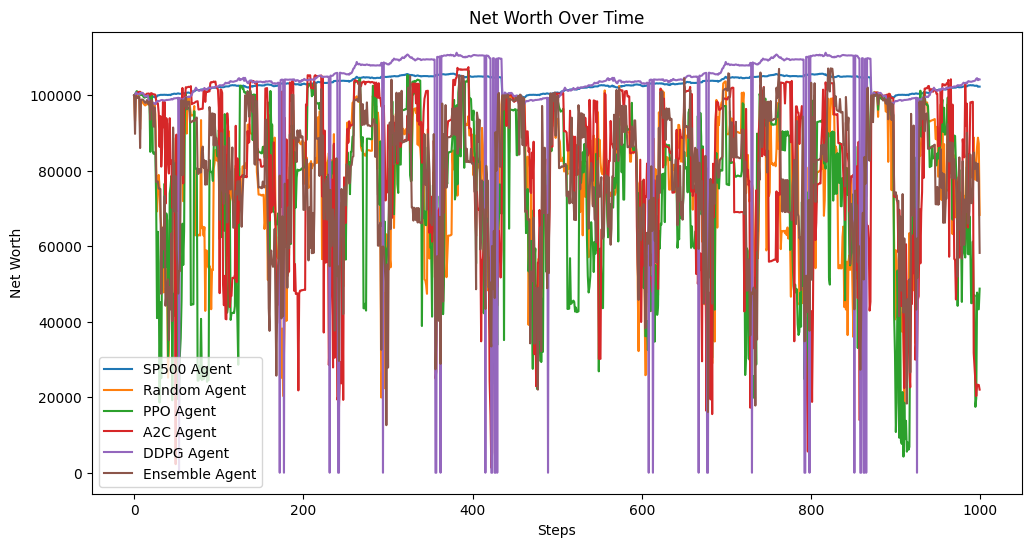

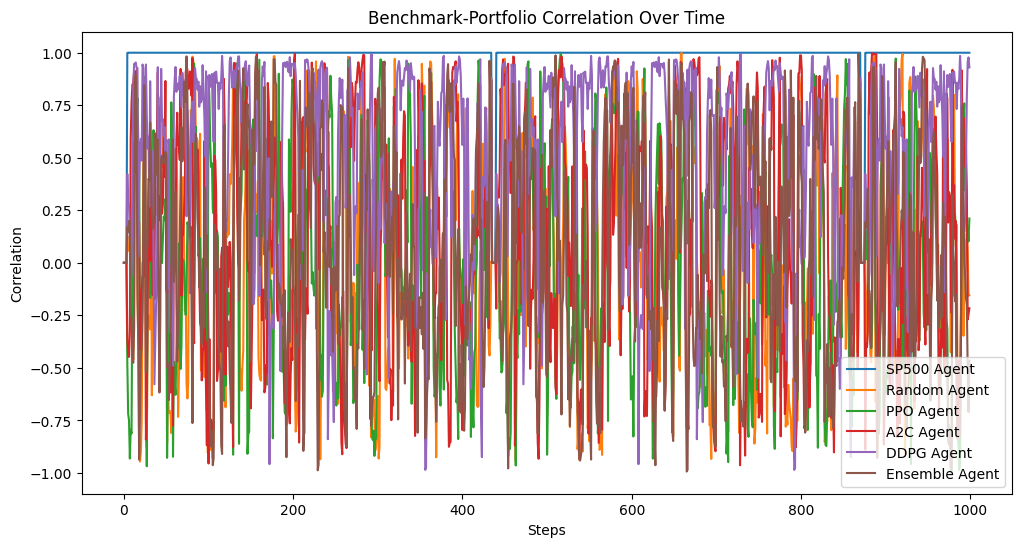

,Agent,Return,Standard Deviation,Sharpe Ratio,Pearson Correlations
0,SP500 Agent,102983.794188,1869.066471,55.099054,0.985998
4,DDPG Agent,101273.287893,19122.862283,5.295927,0.508569
5,Ensemble Agent,77831.286294,17919.257665,4.343444,0.084231
1,Random Agent,74010.996061,18741.548554,3.949033,0.040757
3,A2C Agent,82183.312989,20930.983935,3.926395,0.087398
2,PPO Agent,73855.172192,24302.351112,3.039013,0.078381


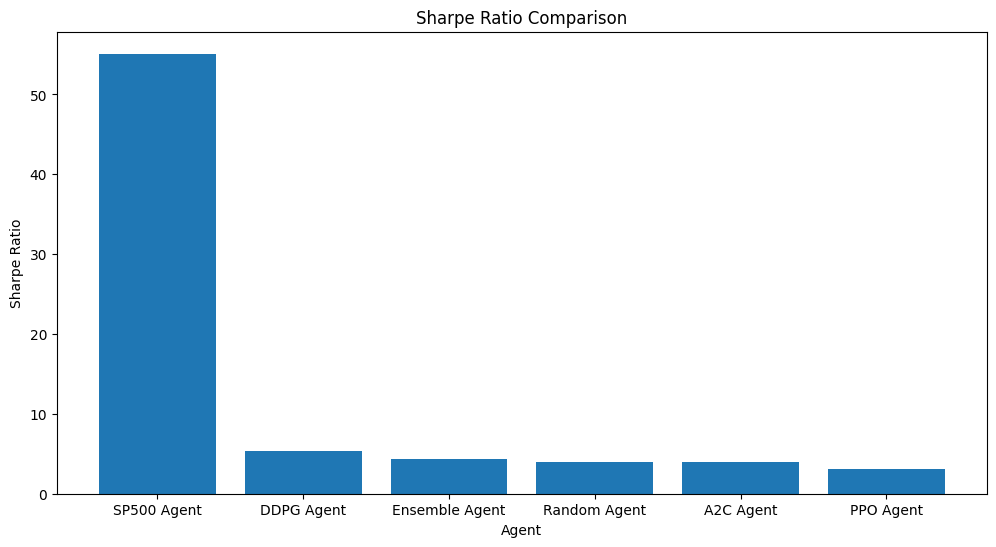

In [15]:
# 1. Create the environment and train the agents
total_timesteps = 10000
env, ppo_agent, a2c_agent, ddpg_agent, random_agent , sp500_agent, ensemble_agent = create_env_and_train_agents(training_data, benchmark_training_data , total_timesteps)

# 2. Test & visualize the agents
n_tests = 1000
agents = {
    'SP500 Agent': sp500_agent,
    'Random Agent': random_agent,
    'PPO Agent': ppo_agent,
    'A2C Agent': a2c_agent,
    'DDPG Agent': ddpg_agent,
    'Ensemble Agent': ensemble_agent
}
test_and_visualize_agents(env, agents, training_data, n_tests=n_tests)

# 3. Compare the agents' performance ( returns, standard deviation, and sharpe ratio )
agents_metrics = [test_agent(env, agent, training_data, n_tests=n_tests, visualize=False) for agent in agents.values()]
compare_and_plot_agents(agents_metrics, list(agents.keys()))

Stock data has been loaded for 24 stocks.
The tickers are: ['AAPL', 'ABCB', 'ABNB', 'CSCO', 'DAL', 'EAST', 'ESPR', 'F', 'FFIE', 'GOOGL', 'JPM', 'META', 'MSFT', 'NVDA', 'PFE', 'PG', 'PSX', 'SGLY', 'SP500', 'TSLA', 'UNH', 'USA', 'WMT', 'XOM']
Testing SP500 Agent...


c:\Users\tcorn\Desktop\RLTesis\DRLST\lib\site-packages\stable_baselines3\common\vec_env\base_vec_env.py:243: UserWarning: You tried to call render() but no `render_mode` was passed to the env constructor.
  warnings.warn("You tried to call render() but no `render_mode` was passed to the env constructor.")


Done testing SP500 Agent!
Testing PPO Agent...
Done testing PPO Agent!
Testing A2C Agent...
Done testing A2C Agent!
Testing DDPG Agent...
Done testing DDPG Agent!
Testing Random Agent...
Done testing Random Agent!
Testing Ensemble Agent...
Done testing Ensemble Agent!
--------------------------------------------------
All agents tested!
--------------------------------------------------


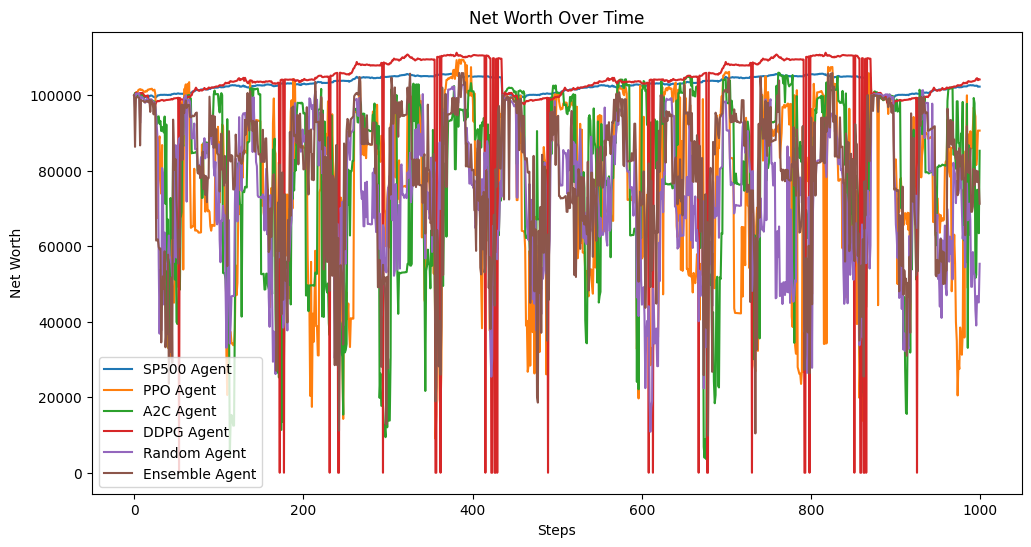

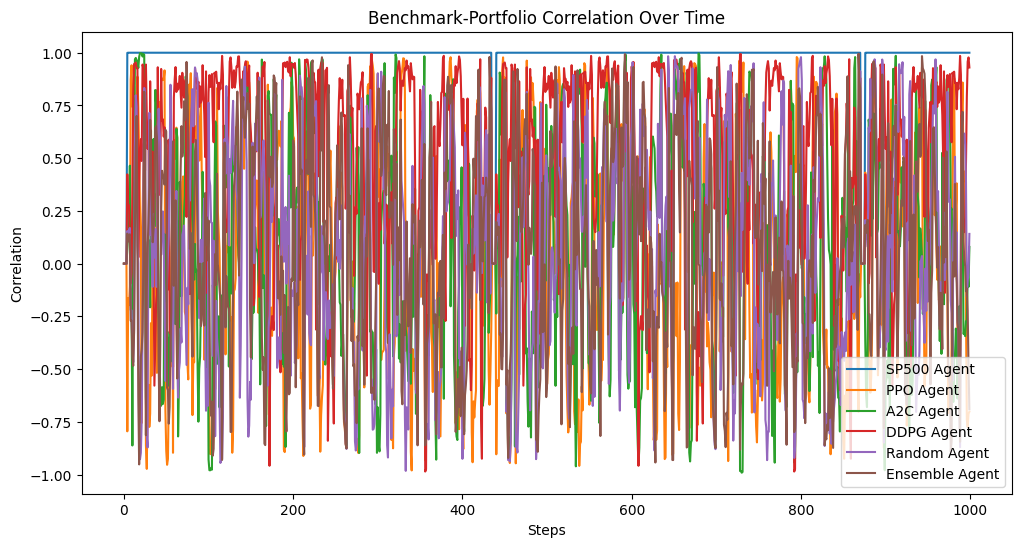

,Agent,Return,Standard Deviation,Sharpe Ratio,Pearson Correlations
0,SP500 Agent,102983.794188,1869.066471,55.099054,0.985998
3,DDPG Agent,101273.287893,19122.862283,5.295927,0.508569
5,Ensemble Agent,77709.872028,18864.117816,4.119454,0.078040
4,Random Agent,73472.965659,19159.793120,3.834747,0.034754
2,A2C Agent,80815.212809,22901.362271,3.528839,0.142774
1,PPO Agent,73188.636626,21427.380649,3.415660,0.058352


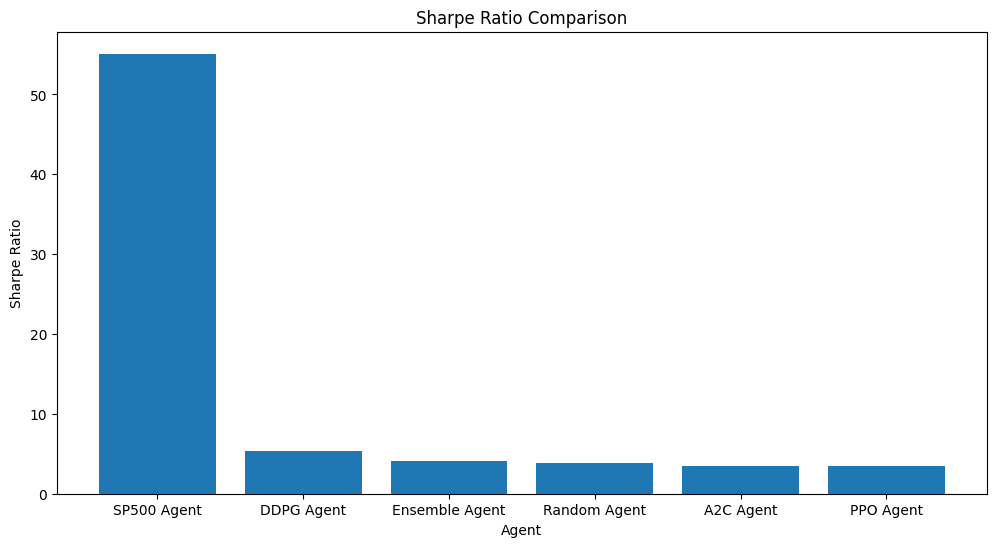

In [16]:
# Create the environment using DummyVecEnv with test data
test_env = DummyVecEnv([lambda: StockTradingEnv(test_data, benchmark_test_data, return_memory_size=5)])

# 2. Test & visualize the agents on the test data
n_tests = 1000
test_agents = {
    'SP500 Agent': sp500_agent,
    'PPO Agent': ppo_agent,
    'A2C Agent': a2c_agent,
    'DDPG Agent': ddpg_agent,
    'Random Agent': random_agent,
    'Ensemble Agent': ensemble_agent
}
test_and_visualize_agents(env, test_agents, test_data, n_tests=n_tests)

# 3. Compare the agents' performance on the test data ( returns, standard deviation, and sharpe ratio )
test_agents_metrics = [test_agent(env, agent, test_data, n_tests=n_tests, visualize=False) for agent in test_agents.values()]
compare_and_plot_agents(test_agents_metrics, list(test_agents.keys()))

In [17]:
def SharesHeldPlot(agents_names, agents_metrics):
    agents_to_plot = agents_names
    for i in range(len(agents_to_plot)):
        #Create the dataframe for shares_held where each row is a ticker , each column is a step and the value is the shares held
        df = pd.DataFrame.from_dict(agents_metrics[i]['shares_held'], orient='index')
        #Filter the rows where the sum of the shares held is greater than 0
        df = df.loc[(df.sum(axis=1) > 0)]
        #Now plot a line char where each line is a ticker and the x axis is the step
        df.T.plot(figsize=(12, 6))
        plt.title(f'Shares Held Over Time for {agents_to_plot[i]}')
        plt.xlabel('Steps')
        plt.ylabel('Shares Held')
        plt.show()

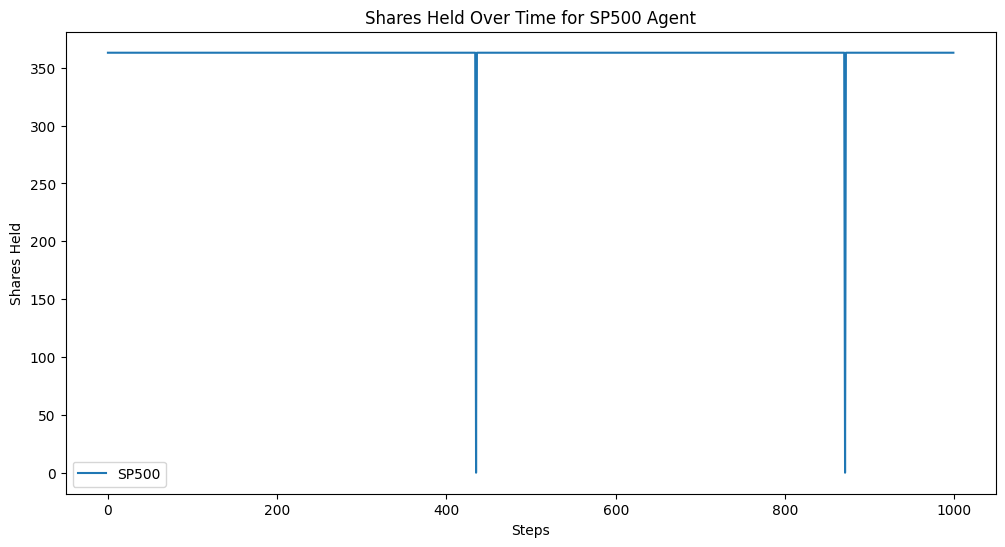

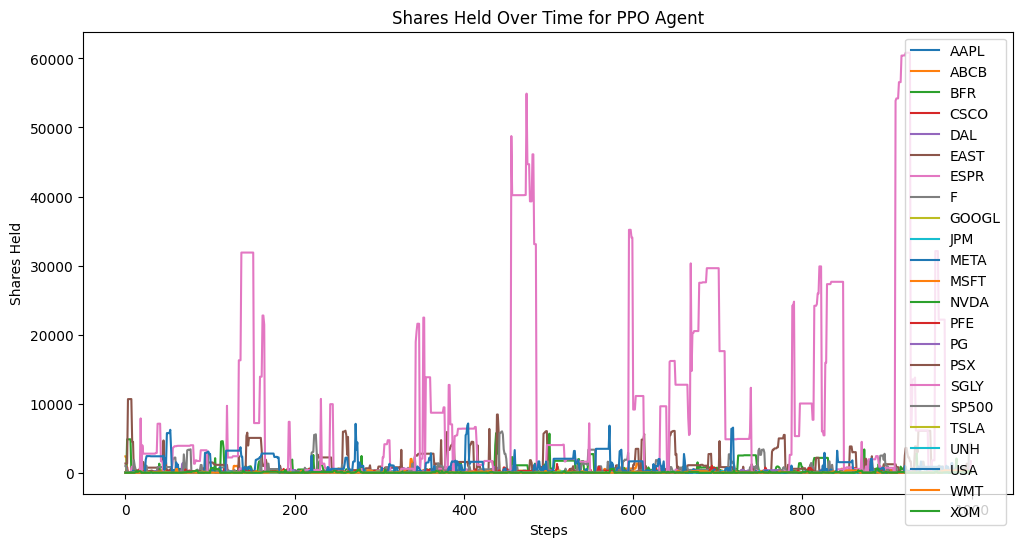

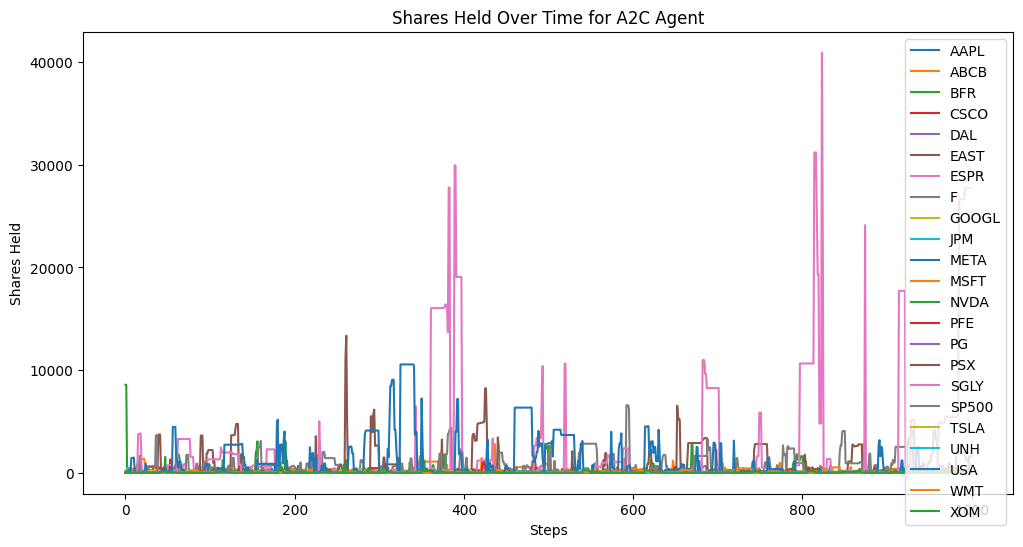

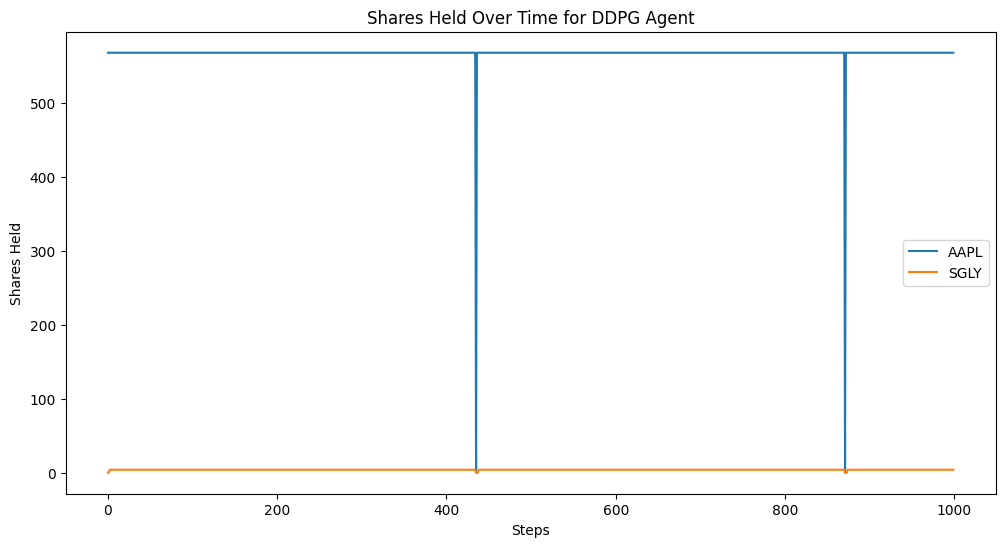

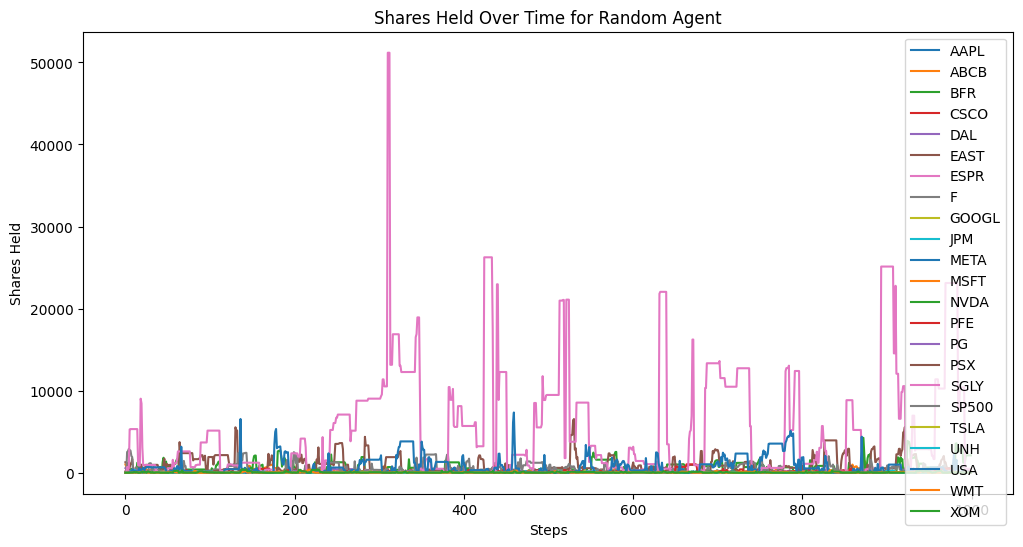

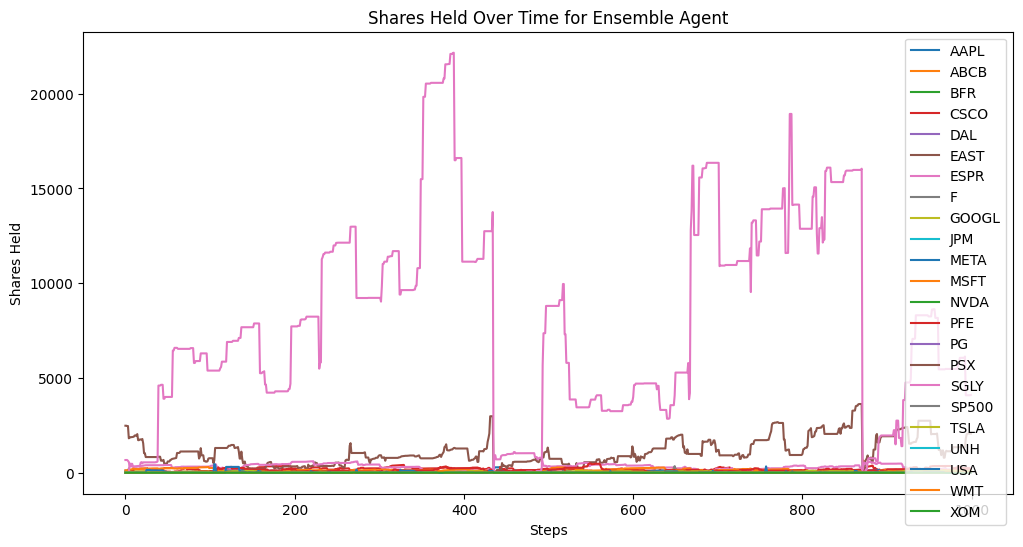

In [18]:
SharesHeldPlot(list(test_agents.keys()), test_agents_metrics)

In [19]:
def BenchmarkCorrelationPlot(agent_name, agents_names, agents_metrics):
    # Get the index of the agent_name from agents_names
    agent_idx = agents_names.index(agent_name)
    #Create the dataframe for shares_held where each row is a ticker , each column is a step and the value is the shares held
    df = pd.DataFrame.from_dict(agents_metrics[agent_idx]['pearson_correlations'])
    #Now plot the line chart where the x axis is the step and the y axis is the correlation
    df.plot(figsize=(12, 6))
    plt.title(f'Benchmark-Portfolio Correlation Over Time for {agent_name}')
    plt.xlabel('Steps')
    plt.ylabel('Correlation')
    plt.show()

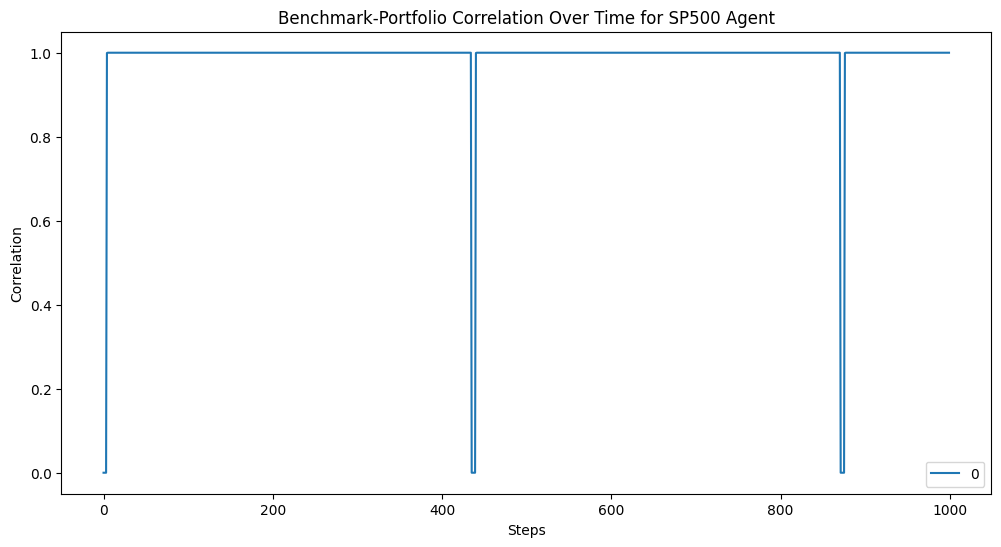

In [20]:
BenchmarkCorrelationPlot("SP500 Agent", list(test_agents.keys()), test_agents_metrics)